In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("gym_churn_synthetic.csv")

In [3]:
df

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,GYM100000,Allison Hill,23.0,Female,"42769 Stone Light Apt. 959, New Jacquelinebury...",323.697.0770x540,Monthly,2024-01-21,2026-05-28,Swimming,64.0,469.0,9367,10.3,No
1,GYM100001,Noah Rhodes,39.0,Male,"911 Courtney Streets Suite 975, North Nancy, I...",+1-945-673-5640x8746,Monthly,2025-07-30,2026-03-17,Yoga,72.0,651.0,7137,13.0,Yes
2,GYM100002,Angie Henderson,35.0,Male,"572 Lawrence Mill, Pattonshire, IN 86699",001-976-322-7203x3428,Monthly,2023-08-26,2026-01-17,Swimming,91.0,644.0,4357,8.8,Yes
3,GYM100003,Daniel Wagner,37.0,Female,"312 Thomas Flat Suite 578, North Christopher, ...",001-527-908-2456x3534,Monthly,2025-02-21,2026-06-07,Cardio,66.0,232.0,6224,13.2,No
4,GYM100004,Cristian Santos,32.0,Female,"594 Alex Mall Suite 495, Albertshire, MH 90338",(585)274-8791x81476,Monthly,2025-10-05,2026-04-21,CrossFit,86.0,650.0,21327,17.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,GYM149995,Kenneth Cantu,41.0,Female,"7682 Jessica Drive, Hillberg, NE 54561",307.589.7733,Monthly,2024-01-03,2026-05-31,Yoga,92.0,667.0,14073,12.8,No
49996,GYM149996,Carmen Wilson,46.0,Female,"743 Ernest Shoal, South Markview, GU 51561",244.605.5399x073,Monthly,2024-08-11,2026-04-14,Swimming,68.0,421.0,2438,7.9,Yes
49997,GYM149997,Rachel Reed,39.0,Male,"48826 Booth Plains Apt. 198, Port Nicole, AL 7...",2792306951,Yearly,2025-04-26,2026-05-07,Cycling,76.0,511.0,4628,12.9,No
49998,GYM149998,April Edwards,80.0,Female,"6437 John Oval Apt. 510, Josephport, AR 81518",640.412.3941x26860,Monthly,2025-04-05,2026-05-14,Cardio,74.0,615.0,6783,17.8,No


In [4]:
# Engineer New Features for Predicting Churn

from sklearn.preprocessing import LabelEncoder

cat_cols = ['Gender', 'Membership_Type', 'Favorite_Exercise'] # Gender          is   Female=0, Male=1, Other=2
                                                              # Membership_Type is   Monthly=0, Quarterly=1, Yearly=2
                                                              # Favorite_Exercise is Cardio=0, CrossFit=1, Cycling=2 ...
                                                              

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

#Churn Conversion
df['Churn'] = (df['Churn'] == 'Yes').astype(int)


today = pd.Timestamp('2026-06-10')

# Parse raw date strings to datetime 
df['Join_Date']       = pd.to_datetime(df['Join_Date'])
df['Last_Visit_Date'] = pd.to_datetime(df['Last_Visit_Date'])

# Engineer date features 
df['tenure_months']        = (today - df['Join_Date']).dt.days / 30
df['days_since_visit']     = (today - df['Last_Visit_Date']).dt.days

df['is_new_member']        = (df['tenure_months'] < 3).astype(int)
df['is_gym_veteran']           = (df['tenure_months'] > 24).astype(int)
df['visited_this_week']    = (df['days_since_visit'] <= 7).astype(int)

df['visit_rate_vs_tenure'] = df['Visits_Per_Month'] / (df['tenure_months'] + 1)

# Drop the raw date columns 
df = df.drop(columns=['Join_Date', 'Last_Visit_Date'])

In [5]:
df

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn,tenure_months,days_since_visit,is_new_member,is_gym_veteran,visited_this_week,visit_rate_vs_tenure
0,GYM100000,Allison Hill,23.0,0,"42769 Stone Light Apt. 959, New Jacquelinebury...",323.697.0770x540,0,5,64.0,469.0,9367,10.3,0,29.033333,13,0,1,0,0.342952
1,GYM100001,Noah Rhodes,39.0,1,"911 Courtney Streets Suite 975, North Nancy, I...",+1-945-673-5640x8746,0,7,72.0,651.0,7137,13.0,1,10.500000,85,0,0,0,1.130435
2,GYM100002,Angie Henderson,35.0,1,"572 Lawrence Mill, Pattonshire, IN 86699",001-976-322-7203x3428,0,5,91.0,644.0,4357,8.8,1,33.966667,144,0,1,0,0.251668
3,GYM100003,Daniel Wagner,37.0,0,"312 Thomas Flat Suite 578, North Christopher, ...",001-527-908-2456x3534,0,0,66.0,232.0,6224,13.2,0,15.800000,3,0,0,1,0.785714
4,GYM100004,Cristian Santos,32.0,0,"594 Alex Mall Suite 495, Albertshire, MH 90338",(585)274-8791x81476,0,1,86.0,650.0,21327,17.7,0,8.266667,50,0,0,0,1.910072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,GYM149995,Kenneth Cantu,41.0,0,"7682 Jessica Drive, Hillberg, NE 54561",307.589.7733,0,7,92.0,667.0,14073,12.8,0,29.633333,10,0,1,0,0.417845
49996,GYM149996,Carmen Wilson,46.0,0,"743 Ernest Shoal, South Markview, GU 51561",244.605.5399x073,0,5,68.0,421.0,2438,7.9,1,22.266667,57,0,0,0,0.339542
49997,GYM149997,Rachel Reed,39.0,1,"48826 Booth Plains Apt. 198, Port Nicole, AL 7...",2792306951,2,2,76.0,511.0,4628,12.9,0,13.666667,34,0,0,0,0.879545
49998,GYM149998,April Edwards,80.0,0,"6437 John Oval Apt. 510, Josephport, AR 81518",640.412.3941x26860,0,0,74.0,615.0,6783,17.8,0,14.366667,27,0,0,0,1.158351


In [6]:
#See missing Data
df.isna().sum()


Member_ID                     0
Name                          0
Age                         779
Gender                        0
Address                       0
Phone_Number                  0
Membership_Type               0
Favorite_Exercise             0
Avg_Workout_Duration_Min    806
Avg_Calories_Burned         702
Total_Weight_Lifted_kg        0
Visits_Per_Month              0
Churn                         0
tenure_months                 0
days_since_visit              0
is_new_member                 0
is_gym_veteran                0
visited_this_week             0
visit_rate_vs_tenure          0
dtype: int64

As you can see, three of the features in the dataset, Age, Avg_Workout_Duration_Min, and Avg_Calories_Burned all have missing data. In order to aid this I am going to fill in that missing data with the median values and then add another feature that indicates that the feature was filled in. This will allow the neural network to receive all of the available data and learn the data that was filled in so it knows when coming up with predictions

In [7]:
# Age, add missingness flag + median fill
df['age_missing'] = df['Age'].isna().astype(int)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Avg_Workout_Duration_Min, add missingness flag + median fill
df['duration_missing'] = df['Avg_Workout_Duration_Min'].isna().astype(int)
df['Avg_Workout_Duration_Min'] = df['Avg_Workout_Duration_Min'].fillna(df['Avg_Workout_Duration_Min'].median())

# Avg_Calories_Burned - missingness flag + median fill (kept for optional use)
df['calories_missing'] = df['Avg_Calories_Burned'].isna().astype(int)
df['Avg_Calories_Burned'] = df['Avg_Calories_Burned'].fillna(df['Avg_Calories_Burned'].median())

# Verify all NaNs are gone
print(df.isna().sum())

# Sanity check flags
print(f"\nRows flagged as age missing: {df['age_missing'].sum()}")
print(f"Rows flagged as duration missing: {df['duration_missing'].sum()}")
print(f"Rows flagged as calories missing: {df['calories_missing'].sum()}")

Member_ID                   0
Name                        0
Age                         0
Gender                      0
Address                     0
Phone_Number                0
Membership_Type             0
Favorite_Exercise           0
Avg_Workout_Duration_Min    0
Avg_Calories_Burned         0
Total_Weight_Lifted_kg      0
Visits_Per_Month            0
Churn                       0
tenure_months               0
days_since_visit            0
is_new_member               0
is_gym_veteran              0
visited_this_week           0
visit_rate_vs_tenure        0
age_missing                 0
duration_missing            0
calories_missing            0
dtype: int64

Rows flagged as age missing: 779
Rows flagged as duration missing: 806
Rows flagged as calories missing: 702


In [8]:
# Print the columns of data
df.columns

Index(['Member_ID', 'Name', 'Age', 'Gender', 'Address', 'Phone_Number',
       'Membership_Type', 'Favorite_Exercise', 'Avg_Workout_Duration_Min',
       'Avg_Calories_Burned', 'Total_Weight_Lifted_kg', 'Visits_Per_Month',
       'Churn', 'tenure_months', 'days_since_visit', 'is_new_member',
       'is_gym_veteran', 'visited_this_week', 'visit_rate_vs_tenure',
       'age_missing', 'duration_missing', 'calories_missing'],
      dtype='str')

In [9]:
# Train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
# Scale the continuous columns in the dataset

continuous_cols = [                 # Scale the continuous columns
    'Age',
    'Avg_Workout_Duration_Min',
    'Visits_Per_Month',
    'tenure_months',
    'days_since_visit',
    'visit_rate_vs_tenure'
]

# Scale on the DataFrame BEFORE splitting
scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])


In [11]:
# Split the Data into feature and target variables
X = df[['Age', 'age_missing', 'Gender', 'Membership_Type', 'Favorite_Exercise', 'Avg_Workout_Duration_Min', 'duration_missing',
        
        # Time and date features
        'Visits_Per_Month', 'tenure_months', 'days_since_visit', 'is_new_member', 'is_gym_veteran', 'visit_rate_vs_tenure']]

y = df['Churn']


In [14]:
# Make train test split
X_train, X_test, y_train, y_test = train_test_split(X,  y,  test_size=0.2, stratify=y, random_state=42)

In [134]:
# Check which columns have NaNs in to ensure nothing is missing
nan_cols = np.isnan(X_train).any(axis=0)
print("Columns with NaN:", np.where(nan_cols)[0])
print("Total NaN values:", np.isnan(X_train).sum())

Columns with NaN: []
Total NaN values: Age                         0
age_missing                 0
Gender                      0
Membership_Type             0
Favorite_Exercise           0
Avg_Workout_Duration_Min    0
duration_missing            0
Visits_Per_Month            0
tenure_months               0
days_since_visit            0
is_new_member               0
is_gym_veteran              0
visit_rate_vs_tenure        0
dtype: int64


In [135]:
# Create Deep Learning model
import torch

In [136]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [137]:
# Create a neural network
import torch.nn as nn

In [138]:
class GymChurnMLP(nn.Module):
    def __init__(self, input_dim):
        super(GymChurnMLP, self).__init__()
        self.network = nn.Sequential(

            # First Layer
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Hidden Layer 1
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Hidden Layer 2
            nn.Linear(32, 16),
            nn.ReLU(),
            
            # Output Layer
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x)

In [139]:
model = GymChurnMLP(X_train_tensor.shape[1])

criterion = nn.BCEWithLogitsLoss() # Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [140]:
# Train Model

epochs = 100

# Run training loop with zero_grad in correct position
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/100, Loss: 0.6797
Epoch 2/100, Loss: 0.6755
Epoch 3/100, Loss: 0.6714
Epoch 4/100, Loss: 0.6673
Epoch 5/100, Loss: 0.6633
Epoch 6/100, Loss: 0.6593
Epoch 7/100, Loss: 0.6560
Epoch 8/100, Loss: 0.6524
Epoch 9/100, Loss: 0.6494
Epoch 10/100, Loss: 0.6463
Epoch 11/100, Loss: 0.6435
Epoch 12/100, Loss: 0.6405
Epoch 13/100, Loss: 0.6371
Epoch 14/100, Loss: 0.6343
Epoch 15/100, Loss: 0.6311
Epoch 16/100, Loss: 0.6282
Epoch 17/100, Loss: 0.6248
Epoch 18/100, Loss: 0.6214
Epoch 19/100, Loss: 0.6178
Epoch 20/100, Loss: 0.6147
Epoch 21/100, Loss: 0.6106
Epoch 22/100, Loss: 0.6071
Epoch 23/100, Loss: 0.6028
Epoch 24/100, Loss: 0.5993
Epoch 25/100, Loss: 0.5955
Epoch 26/100, Loss: 0.5908
Epoch 27/100, Loss: 0.5863
Epoch 28/100, Loss: 0.5816
Epoch 29/100, Loss: 0.5762
Epoch 30/100, Loss: 0.5715
Epoch 31/100, Loss: 0.5668
Epoch 32/100, Loss: 0.5604
Epoch 33/100, Loss: 0.5550
Epoch 34/100, Loss: 0.5489
Epoch 35/100, Loss: 0.5436
Epoch 36/100, Loss: 0.5372
Epoch 37/100, Loss: 0.5306
Epoch 38/1

In [141]:
model.eval()

with torch.no_grad():
    test_logits   = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)

probs_np = probabilities.numpy().flatten()
y_true   = y_test_tensor.numpy().flatten()

print("Prob min:", probs_np.min())
print("Prob max:", probs_np.max())
print("Prob mean:", probs_np.mean())
print("Actual churn rate:", y_true.mean())

Prob min: 0.004307076
Prob max: 0.99878114
Prob mean: 0.30618307
Actual churn rate: 0.3153


In [142]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve,
                             RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt
import numpy as np

# Find optimal threshold via Precision-Recall curve 
precisions, recalls, thresholds = precision_recall_curve(y_true, probs_np)
f1_scores      = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold: {best_threshold:.3f}")
print(f"Best F1 at threshold: {f1_scores[best_idx]:.3f}\n")

# Predictions at both thresholds 
preds_05  = (probs_np >= 0.5).astype(int)
preds_opt = (probs_np >= best_threshold).astype(int)

print("-----Default threshold (0.5)------")
print(confusion_matrix(y_true, preds_05))
print(classification_report(y_true, preds_05,
                             target_names=['Active', 'Churned']))

print(f"\n-----Optimal threshold ({best_threshold:.3f})------")
print(confusion_matrix(y_true, preds_opt))
print(classification_report(y_true, preds_opt,
                             target_names=['Active', 'Churned']))

print(f"ROC AUC: {roc_auc_score(y_true, probs_np):.4f}")

Optimal threshold: 0.405
Best F1 at threshold: 0.804

-----Default threshold (0.5)------
[[6556  291]
 [ 863 2290]]
              precision    recall  f1-score   support

      Active       0.88      0.96      0.92      6847
     Churned       0.89      0.73      0.80      3153

    accuracy                           0.88     10000
   macro avg       0.89      0.84      0.86     10000
weighted avg       0.88      0.88      0.88     10000


-----Optimal threshold (0.405)------
[[6427  420]
 [ 752 2401]]
              precision    recall  f1-score   support

      Active       0.90      0.94      0.92      6847
     Churned       0.85      0.76      0.80      3153

    accuracy                           0.88     10000
   macro avg       0.87      0.85      0.86     10000
weighted avg       0.88      0.88      0.88     10000

ROC AUC: 0.9255


The results on the test data for this model is great, but after further research I have determined that a simpler Machine Learning model using XGBoost would likely be more optimal as limits computational usage necessity while lending itself to higher explainibility between the 13 chosen features in the dataset

-----------

# MACHINE LEARNING MODEL WITH XGBOOST IMPLEMENTATION

In [46]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve)
from sklearn.model_selection import StratifiedKFold
import numpy as np
import joblib

In [47]:
# Calculate pos_weight for class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 2.17


In [48]:
# Define XGBoost model

xgb_model = XGBClassifier(
    n_estimators = 300,             # Number of Trees
    max_depth = 6,                  # depth of each tree
    learning_rate = 0.05,           # the loss shrinkage
    subsample = 0.8,                # % of rows samples per tree
    colsample_bytree = 0.8,          # % of features sampled per tree
    scale_pos_weight = scale_pos_weight,                # handles the class imbalance
    eval_metric = 'auc',
    random_state = 42, 
    n_jobs = -1                     # Use all CPU Cores
)

In [49]:
# Train the model with early stopping


xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_test, y_test)],
    verbose = 50,                    # Print every 50 trees
)

# Retrieve results after fitting
evals_result = xgb_model.evals_result()
print("Training complete.")

[0]	validation_0-auc:0.93945	validation_1-auc:0.93845
[50]	validation_0-auc:0.95028	validation_1-auc:0.94851
[100]	validation_0-auc:0.95288	validation_1-auc:0.94932
[150]	validation_0-auc:0.95538	validation_1-auc:0.94925
[200]	validation_0-auc:0.95896	validation_1-auc:0.94874
[250]	validation_0-auc:0.96338	validation_1-auc:0.94823
[299]	validation_0-auc:0.96702	validation_1-auc:0.94780
Training complete.


In [50]:
# Evaluate model
probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_xgb)
f1_scores      = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

preds_default = (probs_xgb >= 0.5).astype(int)
preds_optimal = (probs_xgb >= best_threshold).astype(int)

print(f"\nOptimal threshold: {best_threshold:.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, probs_xgb):.4f}")

print(f"\n------ Default threshold (0.5) ------")
print(confusion_matrix(y_test, preds_default))
print(classification_report(y_test, preds_default,
                             target_names=['Active', 'Churned']))

print(f"\n------ Optimal threshold ({best_threshold:.3f}) ------")
print(confusion_matrix(y_test, preds_optimal))
print(classification_report(y_test, preds_optimal,
                             target_names=['Active', 'Churned']))


Optimal threshold: 0.551
ROC AUC: 0.9478

------ Default threshold (0.5) ------
[[6485  362]
 [ 602 2551]]
              precision    recall  f1-score   support

      Active       0.92      0.95      0.93      6847
     Churned       0.88      0.81      0.84      3153

    accuracy                           0.90     10000
   macro avg       0.90      0.88      0.89     10000
weighted avg       0.90      0.90      0.90     10000


------ Optimal threshold (0.551) ------
[[6584  263]
 [ 660 2493]]
              precision    recall  f1-score   support

      Active       0.91      0.96      0.93      6847
     Churned       0.90      0.79      0.84      3153

    accuracy                           0.91     10000
   macro avg       0.91      0.88      0.89     10000
weighted avg       0.91      0.91      0.91     10000



On the train test data, the XGBoost model actually performed with a better ROC AUC score. Now it is time to plot the AUC for the training vs validation dataset to see if the data was overfitted

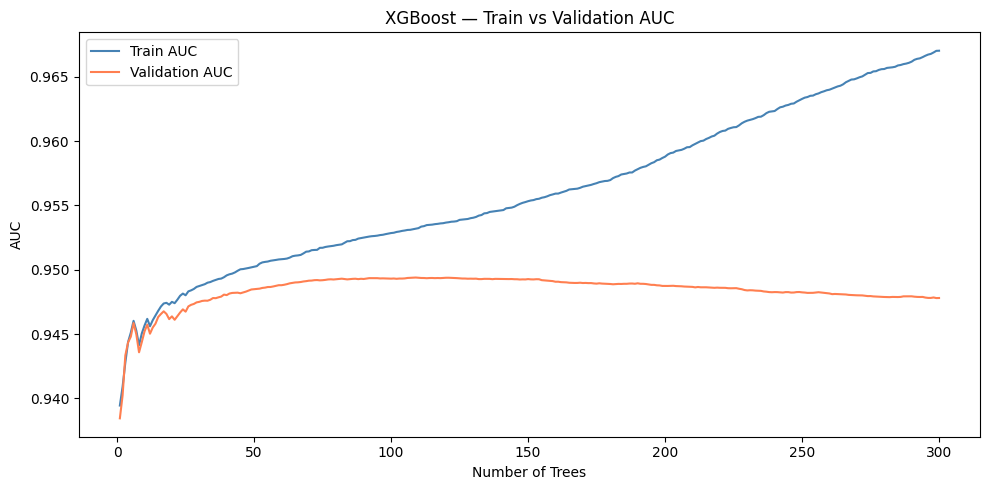

Final Train AUC: 0.9670
Final Val AUC:   0.9478
Gap:             0.0192
No overfitting detected


In [51]:
import matplotlib.pyplot as plt

train_auc = evals_result['validation_0']['auc']
val_auc   = evals_result['validation_1']['auc']
epochs    = range(1, len(train_auc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_auc, label='Train AUC',      color='steelblue')
plt.plot(epochs, val_auc,   label='Validation AUC', color='coral')
plt.xlabel('Number of Trees')
plt.ylabel('AUC')
plt.title('XGBoost — Train vs Validation AUC')
plt.legend()
plt.tight_layout()
plt.show()

final_train_auc = train_auc[-1]
final_val_auc   = val_auc[-1]
gap             = final_train_auc - final_val_auc

print(f"Final Train AUC: {final_train_auc:.4f}")
print(f"Final Val AUC:   {final_val_auc:.4f}")
print(f"Gap:             {gap:.4f}")

if gap < 0.02:
    print("No overfitting detected")
elif gap < 0.05:
    print("Mild overfitting")
else:
    print("Overfitting")

As we can see from the plot, at around 50-75 trees is where the AUC for the number of trees on the validation dataset starts to flatten when the AUC of the training data still rises. In order to reduce the likeliness of overfitting in the model the next step is to decrease the number of trees to around 75 to minimize the amount of overfitting while still allowing the AUC for the validation data to be high.

In [58]:
# REDUCTION OF TREES (n_estimators)

# Define XGBoost model

xgb_model = XGBClassifier(
    n_estimators = 75,             # Number of Trees
    max_depth = 6,                  # depth of each tree
    learning_rate = 0.05,           # the loss shrinkage
    subsample = 0.8,                # % of rows samples per tree
    colsample_bytree = 0.8,          # % of features sampled per tree
    scale_pos_weight = scale_pos_weight,                # handles the class imbalance
    eval_metric = 'auc',
    random_state = 42, 
    n_jobs = -1                     # Use all CPU Cores
)

# Train the model with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_test, y_test)],
    verbose = 25,                    # Print every 25 trees
)

# Retrieve results after fitting
evals_result = xgb_model.evals_result()
print("Training complete.")

[0]	validation_0-auc:0.93945	validation_1-auc:0.93845
[25]	validation_0-auc:0.94832	validation_1-auc:0.94715
[50]	validation_0-auc:0.95028	validation_1-auc:0.94851
[74]	validation_0-auc:0.95171	validation_1-auc:0.94919
Training complete.


In [59]:
# Evaluate model
probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_xgb)
f1_scores      = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

preds_default = (probs_xgb >= 0.5).astype(int)
preds_optimal = (probs_xgb >= best_threshold).astype(int)

print(f"\nOptimal threshold: {best_threshold:.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, probs_xgb):.4f}")

print(f"\n------ Default threshold (0.5) ------")
print(confusion_matrix(y_test, preds_default))
print(classification_report(y_test, preds_default,
                             target_names=['Active', 'Churned']))

print(f"\n------ Optimal threshold ({best_threshold:.3f}) ------")
print(confusion_matrix(y_test, preds_optimal))
print(classification_report(y_test, preds_optimal,
                             target_names=['Active', 'Churned']))


Optimal threshold: 0.558
ROC AUC: 0.9492

------ Default threshold (0.5) ------
[[6463  384]
 [ 598 2555]]
              precision    recall  f1-score   support

      Active       0.92      0.94      0.93      6847
     Churned       0.87      0.81      0.84      3153

    accuracy                           0.90     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.90      0.90      0.90     10000


------ Optimal threshold (0.558) ------
[[6610  237]
 [ 672 2481]]
              precision    recall  f1-score   support

      Active       0.91      0.97      0.94      6847
     Churned       0.91      0.79      0.85      3153

    accuracy                           0.91     10000
   macro avg       0.91      0.88      0.89     10000
weighted avg       0.91      0.91      0.91     10000



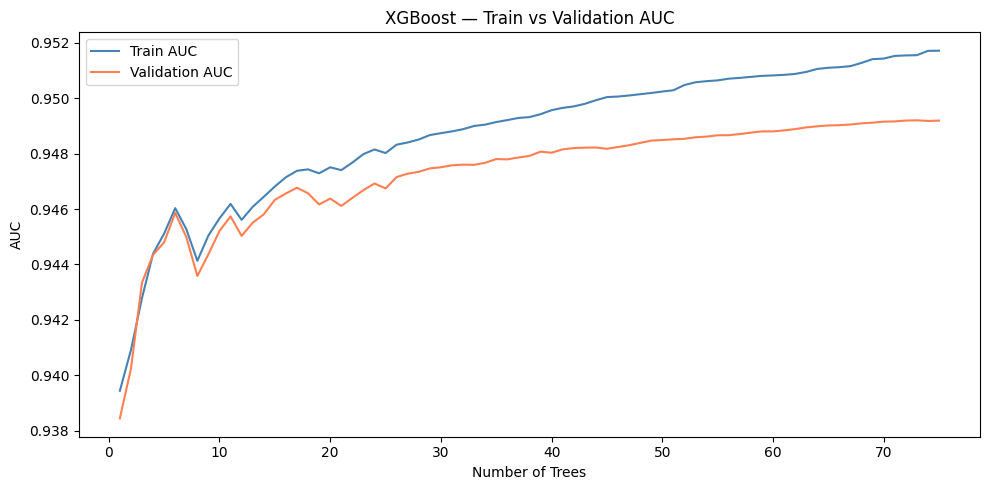

Final Train AUC: 0.9517
Final Val AUC:   0.9492
Gap:             0.0025
No overfitting detected


In [60]:
train_auc = evals_result['validation_0']['auc']
val_auc   = evals_result['validation_1']['auc']
epochs    = range(1, len(train_auc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_auc, label='Train AUC',      color='steelblue')
plt.plot(epochs, val_auc,   label='Validation AUC', color='coral')
plt.xlabel('Number of Trees')
plt.ylabel('AUC')
plt.title('XGBoost — Train vs Validation AUC')
plt.legend()
plt.tight_layout()
plt.show()

final_train_auc = train_auc[-1]
final_val_auc   = val_auc[-1]
gap             = final_train_auc - final_val_auc

print(f"Final Train AUC: {final_train_auc:.4f}")
print(f"Final Val AUC:   {final_val_auc:.4f}")
print(f"Gap:             {gap:.4f}")

if gap < 0.02:
    print("No overfitting detected")
elif gap < 0.05:
    print("Mild overfitting")
else:
    print("Overfitting")